In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
import gc

In [2]:
adata = sc.read_h5ad("mouse_brain_RNA_original.h5ad")
adata

AnnData object with n_obs × n_vars = 3365 × 865
    obs: 'cell_type'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [12]:
genes= db.iloc[:, 2:]
adata=anndata.AnnData(genes)

adata.obs_names=list(db["Unnamed: 0"])
#adata.obs_names=list(db["anat"])
adata.var_names =list(genes.columns.values)
adata.obs['cell_type']=pd.Categorical(db["cell_type"])

#sc.pp.log1p(adata)
adata

/home/mccwen/.local/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 3365 × 865
    obs: 'cell_type'

In [3]:
sc.pp.log1p(adata)
adata

/home/mccwen/.local/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:383: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)


AnnData object with n_obs × n_vars = 3365 × 865
    obs: 'cell_type'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [5]:
# 1. Remove NaNs
adata.X = np.nan_to_num(adata.X, nan=0)

# 2. Highly variable genes (optional but recommended)
sc.pp.highly_variable_genes(adata, flavor='seurat', n_top_genes=2000)
adata = adata[:, adata.var.highly_variable]  # Subset to HVGs

# 3. Scale the data (zero-mean, unit-variance)
sc.pp.scale(adata, max_value=10)

# 4. PCA
sc.tl.pca(adata, svd_solver='arpack')

# 5. Compute neighborhood graph
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50)

# 6. UMAP
sc.tl.umap(adata)
adata

/home/mccwen/.local/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:305: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/home/mccwen/.local/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:412: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  warnings.warn(msg, UserWarning)
/home/mccwen/.local/lib/python3.11/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
2025-04-27 17:00:34.757113: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745787634.774418 2432379 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745

AnnData object with n_obs × n_vars = 3365 × 366
    obs: 'cell_type'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

# Visualization

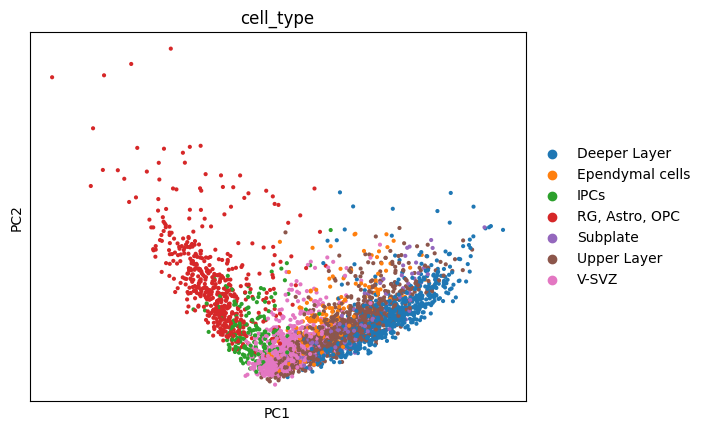

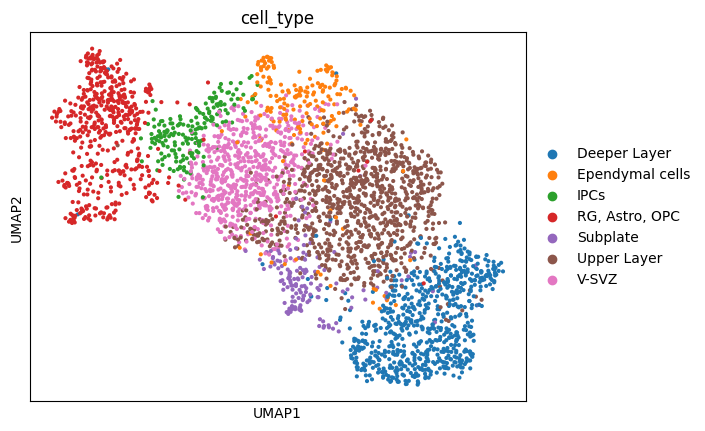

In [6]:
# PCA plot
sc.pl.pca(adata, color='cell_type', show=True)

# UMAP plot
sc.pl.umap(adata, color='cell_type', show=True)

# Split the count matrix to training, test, and validation dataset


In [7]:
from sklearn.model_selection import train_test_split

In [8]:
db = pd.read_csv("mouse_brain_processed_RNA.csv")
print(db["cell_type"].nunique())
db

7


,Unnamed: 0,cell_type,2600014E21Rik,2810403D21Rik,3110099E03Rik,4632427E13Rik,6030442K20Rik,6720427I07Rik,9430041J12Rik,9530051G07Rik,...,Zfp704,Zfp804a,Zfp868,Zfp874b,Zgrf1,Zic1,Zic2,Zic4,Zic5,Zwilch
0,AAACAGCCAACCGCCA-1,Upper Layer,0.0,0.0,0.0,0.693147,0.0,0.0,0.0,0.0,...,1.098612,1.098612,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,AAACAGCCAAGGTCGA-1,"RG, Astro, OPC",0.0,0.0,0.0,0.693147,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,AAACAGCCAGGAACAT-1,Deeper Layer,0.0,0.0,0.0,0.693147,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,AAACAGCCATATTGAC-1,Deeper Layer,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,AAACAGCCATGGTTAT-1,Subplate,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,1.098612,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3360,TTTGTGGCATAATCGT-1,Ependymal cells,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,1.098612,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3361,TTTGTGGCATTTGCTC-1,Upper Layer,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3362,TTTGTGTTCAATGACC-1,IPCs,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.693147,0.0,0.0,0.0,0.0,0.0,0.0
3363,TTTGTTGGTGGAGCAA-1,Deeper Layer,0.0,0.0,0.0,1.098612,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
X= db.iloc[:, 2:]
y= db.iloc[:, 1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_valid, y_test, y_valid = train_test_split(X_test, y_test, test_size= 0.3, random_state= 42)

print(X_train.shape, X_test.shape, X_valid.shape, y_train.shape, y_test.shape, y_valid.shape)
print(X.shape)

(2355, 865) (707, 865) (303, 865) (2355,) (707,) (303,)
(3365, 865)


# Class for classification

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [11]:
class TransformerClassifier(nn.Module):
    def __init__(self, embedding_dim, num_classes, num_heads=4, num_layers=2, hidden_dim=128):
        super(TransformerClassifier, self).__init__()
        self.embedding = nn.Linear(embedding_dim, hidden_dim)
        encoder_layers = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.embedding(x)  # Project input to hidden dimension
        x = x.unsqueeze(1)  # Ensure shape is (batch_size, seq_length=1, hidden_dim)
        x = self.transformer_encoder(x)  # Transformer encoder expects (seq_length, batch_size, hidden_dim)
        x = x.squeeze(1)  # Remove extra dimension
        logits = self.fc(x)  # Aggregate features along embedding space
        return self.softmax(logits)


In [16]:
# Training function
def train_classifier(X_train, y_train, X_validation, y_validation, X_test, y_test, embedding_dim, num_classes, epochs=10, lr=0.001, batch_size=32):
    model = TransformerClassifier(embedding_dim, num_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = TensorDataset(X_validation, y_validation)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_dataset = TensorDataset(X_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        # Validation step
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                val_loss += criterion(outputs, labels).item()
        
        print(f'Epoch [{epoch+1}/{epochs}], Training Loss: {loss.item():.4f}, Validation Loss: {val_loss / len(val_loader):.4f}')
    
    return model


# Prediction function
def predict(model, X_test):
    with torch.no_grad():
        outputs = model(X_test)
        predicted_labels = torch.argmax(outputs, dim=1)
    return predicted_labels

In [12]:
from sklearn.preprocessing import LabelEncoder
# Initialize LabelEncoder
label_encoder = LabelEncoder()

In [13]:
# Fit on all labels and transform them
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
y_valid_encoded = label_encoder.transform(y_valid)

In [14]:
# Assuming your datasets are in NumPy arrays, convert them to PyTorch tensors
# Convert Pandas Series to NumPy arrays
X_train_tensor = torch.tensor(np.array(X_train), dtype=torch.float32)
X_test_tensor = torch.tensor(np.array(X_test), dtype=torch.float32)
X_valid_tensor = torch.tensor(np.array(X_valid), dtype=torch.float32)

# Convert labels to NumPy arrays with explicit integer conversion
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)
y_valid_tensor = torch.tensor(y_valid_encoded, dtype=torch.long)

In [17]:
# Define parameters
embedding_dim = 865  # Based on input shape, i.e., gene number
#num_classes = len(torch.unique(y_train_tensor))  # Automatically infer number of classes
num_classes = 7 # Because we have a total of 18 different cell types in our input data
epochs = 20  # Adjust based on training needs
lr = 0.001
batch_size = 32

# Train the model
model = train_classifier(
    X_train_tensor, y_train_tensor,
    X_valid_tensor, y_valid_tensor,
    X_test_tensor, y_test_tensor,
    embedding_dim, num_classes, 
    epochs=epochs, lr=lr, batch_size=batch_size
)

/home/mccwen/.local/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch [1/20], Training Loss: 1.6171, Validation Loss: 1.3734
Epoch [2/20], Training Loss: 1.2195, Validation Loss: 1.3360
Epoch [3/20], Training Loss: 1.1661, Validation Loss: 1.3935
Epoch [4/20], Training Loss: 1.2942, Validation Loss: 1.3182
Epoch [5/20], Training Loss: 1.2820, Validation Loss: 1.3446
Epoch [6/20], Training Loss: 1.4741, Validation Loss: 1.3275
Epoch [7/20], Training Loss: 1.4114, Validation Loss: 1.3502
Epoch [8/20], Training Loss: 1.2309, Validation Loss: 1.3016
Epoch [9/20], Training Loss: 1.2206, Validation Loss: 1.2842
Epoch [10/20], Training Loss: 1.2196, Validation Loss: 1.2881
Epoch [11/20], Training Loss: 1.2709, Validation Loss: 1.2656
Epoch [12/20], Training Loss: 1.3758, Validation Loss: 1.2778
Epoch [13/20], Training Loss: 1.2709, Validation Loss: 1.2736
Epoch [14/20], Training Loss: 1.2732, Validation Loss: 1.2495
Epoch [15/20], Training Loss: 1.3235, Validation Loss: 1.2514
Epoch [16/20], Training Loss: 1.3822, Validation Loss: 1.3188
Epoch [17/20], Tr

In [18]:
predicted_labels = predict(model, X_test_tensor)
print("Predicted Labels:", predicted_labels)

Predicted Labels: tensor([1, 6, 3, 1, 3, 5, 6, 5, 6, 0, 3, 5, 2, 0, 0, 1, 0, 5, 3, 0, 5, 0, 0, 5,
        0, 6, 5, 0, 0, 1, 6, 5, 3, 5, 1, 0, 1, 3, 0, 3, 6, 6, 5, 0, 3, 5, 3, 0,
        0, 0, 0, 6, 0, 1, 5, 5, 6, 5, 2, 0, 6, 6, 0, 1, 5, 0, 0, 5, 2, 6, 3, 5,
        6, 3, 2, 5, 3, 0, 5, 5, 3, 0, 3, 0, 5, 5, 6, 3, 3, 6, 5, 2, 0, 5, 1, 6,
        1, 5, 5, 5, 3, 0, 3, 5, 5, 5, 3, 5, 5, 6, 6, 6, 5, 2, 0, 3, 0, 5, 5, 6,
        5, 3, 2, 5, 6, 0, 6, 1, 6, 3, 3, 0, 0, 1, 0, 0, 2, 5, 6, 3, 5, 0, 0, 0,
        6, 0, 5, 5, 0, 3, 5, 0, 5, 0, 5, 1, 3, 5, 3, 0, 6, 1, 6, 3, 6, 6, 5, 6,
        5, 5, 1, 3, 5, 6, 0, 3, 2, 3, 5, 5, 6, 1, 5, 5, 1, 0, 6, 3, 0, 5, 0, 5,
        5, 5, 5, 5, 5, 6, 0, 2, 5, 5, 5, 0, 6, 3, 5, 5, 1, 0, 0, 5, 0, 3, 3, 1,
        1, 1, 0, 5, 5, 5, 6, 5, 5, 5, 5, 0, 5, 6, 5, 0, 6, 0, 5, 6, 0, 1, 3, 2,
        3, 0, 3, 5, 5, 6, 6, 5, 0, 0, 6, 0, 0, 6, 6, 1, 3, 2, 5, 5, 0, 6, 6, 6,
        1, 3, 1, 6, 5, 1, 1, 2, 5, 3, 3, 0, 0, 0, 1, 5, 1, 0, 5, 1, 5, 3, 0, 5,
        6, 0, 0, 0, 0,

Accuracy: 0.9080622347949081


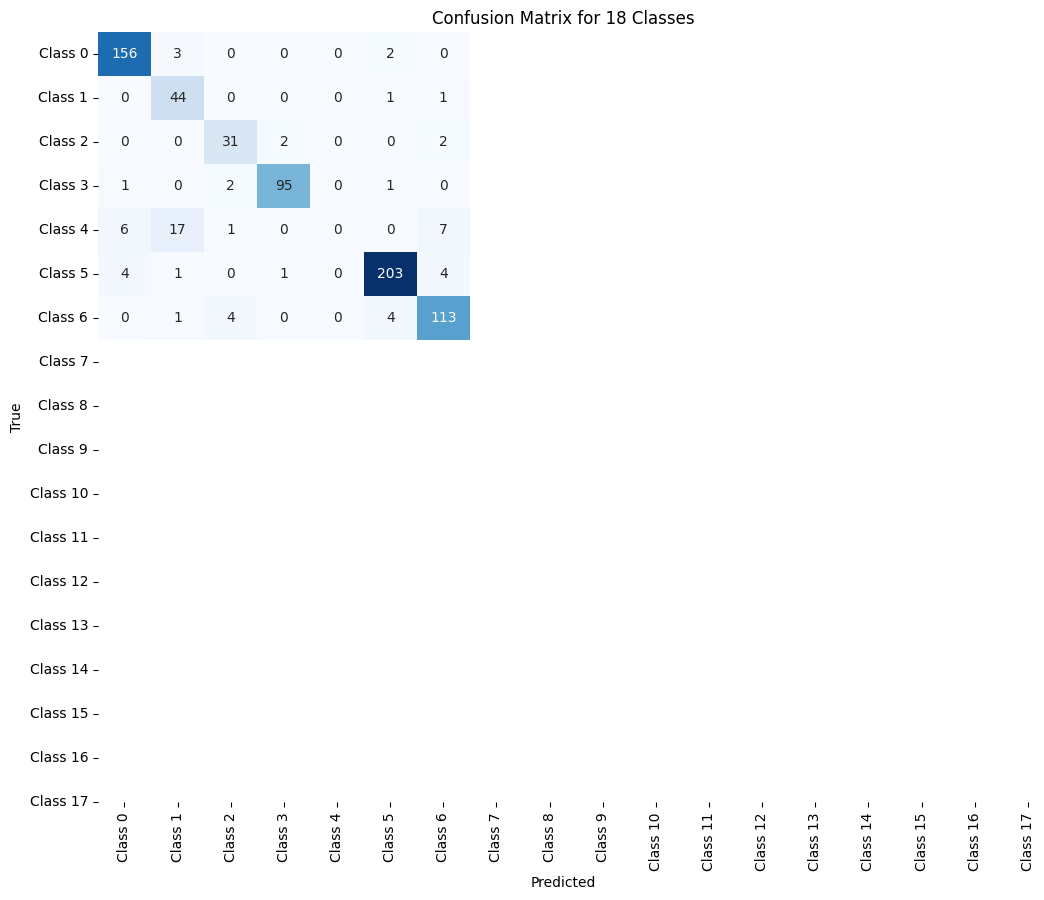

Classification report:               precision    recall  f1-score   support

           0       0.93      0.97      0.95       161
           1       0.67      0.96      0.79        46
           2       0.82      0.89      0.85        35
           3       0.97      0.96      0.96        99
           4       0.00      0.00      0.00        31
           5       0.96      0.95      0.96       213
           6       0.89      0.93      0.91       122

    accuracy                           0.91       707
   macro avg       0.75      0.81      0.77       707
weighted avg       0.88      0.91      0.89       707



/home/mccwen/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mccwen/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mccwen/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
# Compare true cell types with predicted ones for the test data
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_recall_curve, precision_score, recall_score
accuracy =accuracy_score(y_test_tensor, predicted_labels)
print(f"Accuracy: {accuracy}")

conf_matrix = confusion_matrix(y_test_tensor, predicted_labels)
#print(f"Confusion Matrix:\n{conf_matrix}")
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[f'Class {i}' for i in range(18)],
            yticklabels=[f'Class {i}' for i in range(18)], cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for 18 Classes')
plt.xticks(rotation=90)
plt.show()

report= classification_report(y_test_tensor, predicted_labels)
print(f"Classification report: {report}")

In [20]:
# Calculate F1 score for multi-class classification with 'weighted' average
f1 = f1_score(y_test_tensor, predicted_labels, average='macro')
print(f"F1 Score (Macro): {f1}")

# Calculate F1 score for multi-class classification with 'micro' average
f1_micro = f1_score(y_test_tensor, predicted_labels, average='micro')
print(f"F1 Score (Micro): {f1_micro}")

precision_macro = precision_score(y_test_tensor, predicted_labels, average='macro', labels=range(18))
recall_macro = recall_score(y_test_tensor, predicted_labels, average='macro', labels=range(18))
f1_macro = f1_score(y_test_tensor, predicted_labels, average='macro', labels=range(18))
print(f"Test precision: {precision_macro: .3f}")
print(f"Test recall: {recall_macro: .3f}")
print(f"Test F1 score: {f1_macro: .3f}")

F1 Score (Macro): 0.7736990804826248
F1 Score (Micro): 0.9080622347949081
Test precision:  0.291
Test recall:  0.314
Test F1 score:  0.301


/home/mccwen/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mccwen/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mccwen/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


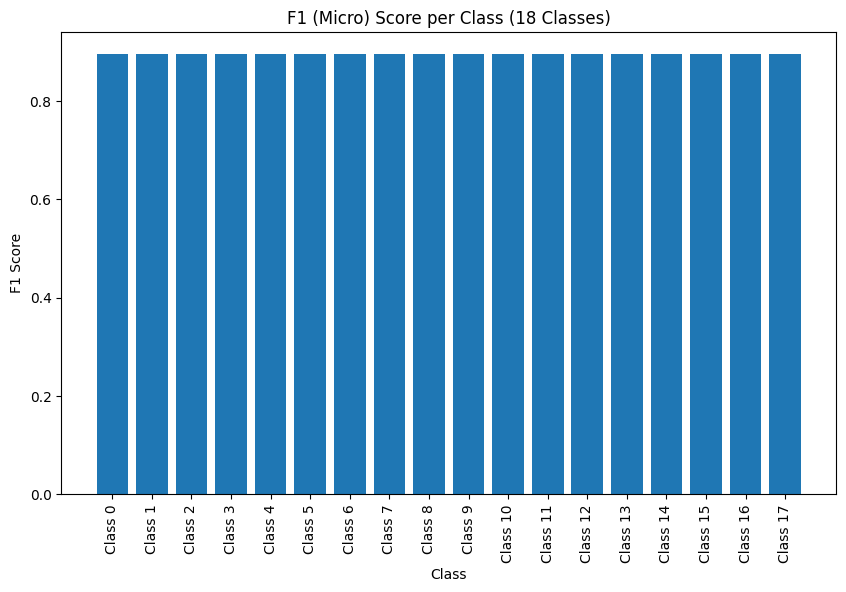

In [31]:
# Plot F1 score per class
plt.figure(figsize=(10, 6))
plt.bar(range(18), f1_micro )
plt.xticks(range(18), [f'Class {i}' for i in range(18)], rotation=90)
plt.xlabel('Class')
plt.ylabel('F1 Score')
plt.title('F1 (Micro) Score per Class (18 Classes)')
plt.show()

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Calculate accuracy for each class
accuracy_per_class = []
for i in range(7):  # For each class
    class_mask = (y_test_tensor == i)
    class_accuracy = accuracy_score(y_test_tensor[class_mask], predicted_labels[class_mask])
    accuracy_per_class.append(class_accuracy)

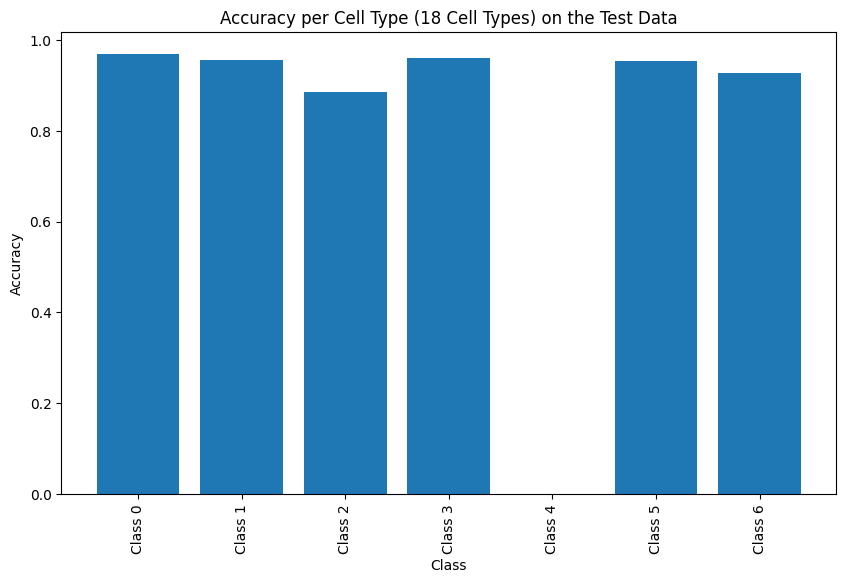

In [22]:
# Plot accuracy per class
plt.figure(figsize=(10, 6))
plt.bar(range(7), accuracy_per_class)
plt.xticks(range(7), [f'Class {i}' for i in range(7)], rotation=90)
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Accuracy per Cell Type (18 Cell Types) on the Test Data')
plt.savefig("gene_exp_based_Accuracy_per_celltype_TestData.png")
plt.show()

# Validation dataset

In [23]:
#Compare the true cell types with the predicted ones on validation data
valid_predicted_labels = predict(model, X_valid_tensor)
accuracy =accuracy_score(y_valid_tensor, valid_predicted_labels)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9141914191419142


In [24]:
# Calculate F1 score for multi-class classification with 'weighted' average
f1 = f1_score(y_valid_tensor, valid_predicted_labels, average='macro')
print(f"F1 Score (Macro): {f1}")

# Calculate F1 score for multi-class classification with 'micro' average
f1_micro = f1_score(y_valid_tensor, valid_predicted_labels, average='micro')
print(f"F1 Score (Micro): {f1_micro}")

precision_macro = precision_score(y_valid_tensor, valid_predicted_labels, average='macro', labels=range(18))
recall_macro = recall_score(y_valid_tensor, valid_predicted_labels, average='macro', labels=range(18))
f1_macro = f1_score(y_valid_tensor, valid_predicted_labels, average='macro', labels=range(18))
print(f"Validation precision: {precision_macro: .3f}")
print(f"Validation recall: {recall_macro: .3f}")
print(f"Validation F1 score: {f1_macro: .3f}")

F1 Score (Macro): 0.783411340235886
F1 Score (Micro): 0.9141914191419142
Validation precision:  0.295
Validation recall:  0.317
Validation F1 score:  0.305


/home/mccwen/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mccwen/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mccwen/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Calculate accuracy for each class
accuracy_per_class = []
for i in range(7):  # For each class
    class_mask = (y_valid_tensor == i)
    class_accuracy = accuracy_score(y_valid_tensor[class_mask], valid_predicted_labels[class_mask])
    accuracy_per_class.append(class_accuracy)

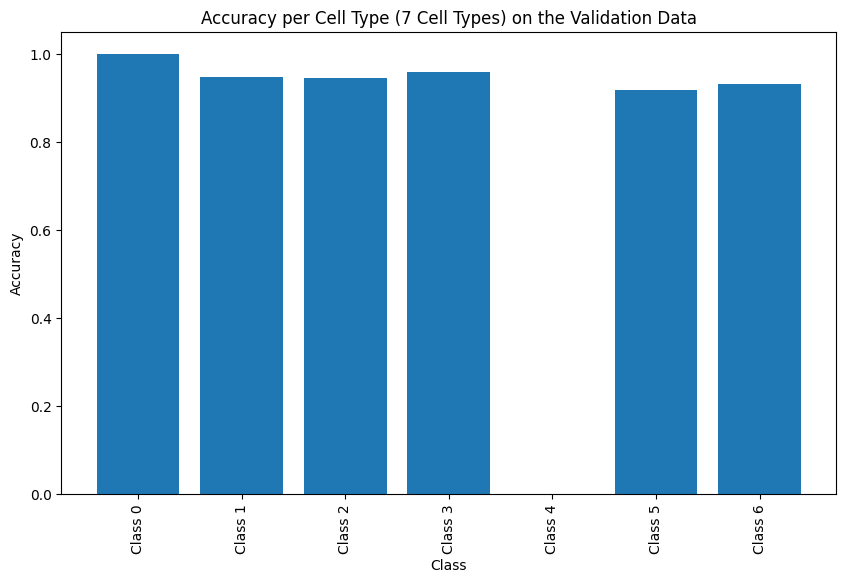

In [26]:
# Plot accuracy per class
plt.figure(figsize=(10, 6))
plt.bar(range(7), accuracy_per_class)
plt.xticks(range(7), [f'Class {i}' for i in range(7)], rotation=90)
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Accuracy per Cell Type (7 Cell Types) on the Validation Data')
plt.savefig("gene_exp_Accuracy_per_celltype_ValidData.png")
plt.show()

# Use scFoundation's embedded data

## Can NOT run scFoundation on non-human gene expression data as its features are catered to human genes